# SQL 데이터베이스와 상호작용하는 에이전트

이 튜토리얼에서는 **SQL 데이터베이스에 대한 질문에 답할 수 있는 에이전트**를 단계별로 구축하는 방법을 소개합니다.  

SQL 쿼리를 실행하는 에이전트의 흐름은 다음과 같습니다.

1. **데이터베이스 스키마 파악**: 사용 가능한 테이블 목록을 가져옵니다.
2. **관련 테이블 선택**: 질문과 연관된 테이블을 선택합니다.
3. **DDL 조회**: 선택된 테이블의 스키마 정의(DDL)를 가져옵니다.
4. **쿼리 생성**: 질문과 DDL 정보에 기반하여 SQL 쿼리를 작성합니다.
5. **쿼리 점검**: LLM을 사용하여 일반적인 오류를 검토하고 쿼리를 개선합니다.
6. **쿼리 실행 및 오류 처리**: 데이터베이스 엔진에 쿼리를 실행하고, 오류 발생 시 수정하여 성공적으로 쿼리를 수행합니다.
7. **응답 생성**: 쿼리 결과를 기반으로 최종 답변을 제공합니다.

![](./assets/langgraph-sql-agent.png)

---

**주요 내용**

- **데이터베이스**: SQLite 데이터베이스 설정 및 `chinook` 샘플 데이터베이스 로드  
- **유틸리티 함수**: 에이전트 구현을 위한 유틸리티 함수 정의  
- **도구 정의**: 데이터베이스와 상호작용하기 위한 도구 정의  
- **워크플로우 정의**: 에이전트의 워크플로우(그래프) 정의  
- **그래프 시각화**: 정의된 그래프 시각화  
- **에이전트 실행**: 에이전트 실행 및 결과 확인  
- **평가**: 에이전트 평가 및 성능 비교  

## 환경 설정

SQL Agent를 구현하기 위해 필요한 환경을 설정합니다. API 키를 환경변수로 관리하고, LangSmith를 통해 실행 과정을 추적할 수 있도록 설정합니다.

아래 코드는 `.env` 파일에서 API 키를 로드하고 LangSmith 추적을 활성화합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Use-Cases")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Use-Cases


In [3]:
from langchain.chat_models import init_chat_model

# OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

## 데이터베이스 설정

이 튜토리얼에서는 SQLite 데이터베이스를 사용하여 SQL Agent를 구현합니다. SQLite는 별도의 서버 설치 없이 파일 하나로 동작하는 경량 내장형 데이터베이스로, Python 표준 라이브러리에 포함되어 있어 추가 설치 없이 바로 활용할 수 있습니다. 로컬 개발 환경에서 SQL 에이전트를 프로토타이핑하고 실험하기에 최적화된 선택입니다.

이번 튜토리얼에서는 샘플 데이터베이스인 `chinook` 데이터베이스를 로드할 예정입니다. Chinook 데이터베이스는 디지털 미디어 스토어를 시뮬레이션한 데이터로, `Artist`, `Album`, `Track`, `Customer`, `Invoice` 등 11개의 테이블로 구성되어 있습니다. 음악, 고객, 직원, 판매 등 다양한 도메인의 관계형 데이터를 포함하고 있어 SQL 학습 및 에이전트 테스트에 널리 활용되는 표준 샘플 데이터베이스입니다.

데이터베이스에 대한 자세한 정보는 [여기](https://www.sqlitetutorial.net/sqlite-sample-database/)에서 확인할 수 있습니다.

먼저, 실습에 활용할 `chinook` 데이터베이스를 다운로드 받습니다. 이 데이터베이스는 디지털 미디어 스토어의 샘플 데이터를 포함하고 있습니다.

In [4]:
import requests

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"

response = requests.get(url)

if response.status_code == 200:
    with open("Chinook.db", "wb") as file:
        file.write(response.content)
    print("File downloaded and saved as Chinook.db")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved as Chinook.db


다음은 다운로드 받은 `chinook` 데이터베이스를 사용하여 `SQLDatabase` 도구를 생성합니다. `SQLDatabase`는 LangChain에서 제공하는 SQL 데이터베이스 연결 유틸리티입니다.

아래 코드는 데이터베이스에 연결하고, 사용 가능한 테이블 목록을 확인한 후, 샘플 쿼리를 실행합니다.

In [5]:
from langchain_community.utilities import SQLDatabase

# SQLite 데이터베이스 파일에서 SQLDatabase 인스턴스 생성
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

# DB dialect 출력(sqlite)
print(db.dialect)

# 데이터베이스에서 사용 가능한 테이블 이름 목록 출력
print(db.get_usable_table_names())

# SQL 쿼리 실행
db.run("SELECT * FROM Artist LIMIT 5;")

sqlite
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]"

## 유틸리티 함수

에이전트 구현을 돕기 위해 몇 가지 유틸리티 함수를 정의합니다. 특히, `ToolNode`를 **오류 처리**와 **에이전트에 오류를 전달하는 기능**을 포함하여 래핑합니다.

오류가 발생하면 에이전트에게 오류 메시지를 전달하여 쿼리를 수정하고 재시도할 수 있도록 합니다. 아래 코드는 오류 처리 함수와 fallback이 포함된 ToolNode 생성 함수를 정의합니다.

In [6]:
from typing import Any

from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph.prebuilt import ToolNode


# 오류 처리 함수
def handle_tool_error(state) -> dict:
    # 오류 정보 조회
    error = state.get("error")
    # 도구 정보 조회
    tool_calls = state["messages"][-1].tool_calls
    # ToolMessage 로 래핑 후 반환
    return {
        "messages": [
            ToolMessage(
                content=f"Here is the error: {repr(error)}\n\nPlease fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


# 오류를 처리하고 에이전트에 오류를 전달하기 위한 ToolNode 생성
def create_tool_node_with_fallback(tools: list) -> RunnableWithFallbacks[Any, dict]:
    """오류를 처리하고 에이전트에 오류 내용을 전달하는 ToolNode를 생성합니다.

    오류 발생 시 handle_tool_error 함수를 대체 동작(fallback)으로 실행하여,
    에이전트가 오류 내용을 인지하고 쿼리를 수정할 수 있도록 합니다.
    """
    # 오류 발생 시 대체 동작을 정의하여 ToolNode에 추가
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )

## SQL 쿼리 실행 도구 

에이전트가 데이터베이스와 상호작용할 수 있도록 몇 가지 도구를 정의합니다.

1. `list_tables_tool`: 데이터베이스에서 사용 가능한 테이블을 가져옵니다.
2. `get_schema_tool`: 테이블의 DDL을 가져옵니다.
3. `db_query_tool`: 쿼리를 실행하고 결과를 가져오거나 쿼리가 실패할 경우 오류 메시지를 반환합니다.

**참고**

- DDL(데이터 정의 언어, **Data Definition Language**)은 데이터베이스의 구조와 스키마를 정의하거나 수정하는 데 사용되는 SQL 명령어들을 지칭합니다. 주로 테이블, 인덱스, 뷰, 스키마 등의 데이터베이스 객체를 생성, 수정, 삭제할 때 사용됩니다.

주요 DDL 명령어

- **`CREATE`**: 데이터베이스 객체를 생성합니다.
  - 예: `CREATE TABLE users (id INT, name VARCHAR(100));`
- **`ALTER`**: 기존 데이터베이스 객체를 수정합니다.
  - 예: `ALTER TABLE users ADD COLUMN email VARCHAR(100);`
- **`DROP`**: 데이터베이스 객체를 삭제합니다.
  - 예: `DROP TABLE users;`

### 데이터베이스 쿼리 관련 도구

`SQLDatabaseToolkit`은 LangChain에서 제공하는 SQL 데이터베이스 전용 툴킷으로, 데이터베이스와 상호작용하는 데 필요한 도구들을 하나의 패키지로 묶어 제공합니다. 이 툴킷을 활용하면 테이블 목록 조회, 스키마 확인, 쿼리 실행, 쿼리 유효성 검사 등의 기능을 별도로 정의하지 않고도 에이전트에 손쉽게 통합할 수 있습니다. `SQLDatabaseToolkit(db=db, llm=llm)`과 같이 데이터베이스 연결 객체와 LLM 인스턴스를 전달하면, `get_tools()` 메서드를 통해 아래 4가지 도구를 즉시 사용할 수 있습니다.

> 📖 **참고 문서**: [SQLDatabaseToolkit](https://python.langchain.com/docs/integrations/toolkits/sql_database/)

다음은 SQL database와 상호작용하기 위한 `SQLDatabaseToolkit` 도구 목록입니다.

**QuerySQLDataBaseTool**

- **기능**: SQL query 실행 및 결과 반환
- **Input**: 정확한 SQL query
- **Output**: Database 결과 또는 error message
- **Error 처리**:
  - Query 오류 발생 시 재작성 및 재시도
  - `Unknown column` 오류 시 `sql_db_schema`로 정확한 table fields 확인

**InfoSQLDatabaseTool**

- **기능**: Table schema 및 sample data 조회
- **Input**: 콤마로 구분된 table 목록
- **사용 예시**: `table1, table2, table3`
- **주의사항**: `sql_db_list_tables`로 table 존재 여부 사전 확인 필요

**ListSQLDatabaseTool**

- **기능**: Database 내 table 목록 조회

**QuerySQLCheckerTool**

- **기능**: Query 실행 전 유효성 검사
- **검사 항목**:
  - NULL 값과 NOT IN 사용
  - UNION vs UNION ALL 적절성
  - BETWEEN 범위 설정
  - Data type 일치 여부
  - Identifier 인용 적절성
  - Function argument 수
  - Data type casting
  - Join column 정확성
- **특징**: LLM 기반 검증 수행

In [7]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain.chat_models import init_chat_model

# SQLDatabaseToolkit 생성
# OpenAI 키를 사용하는 경우 gpt-4.1-mini 등의 모델로 변경하세요
toolkit = SQLDatabaseToolkit(db=db, llm=init_chat_model("claude-sonnet-4-5"))

# SQLDatabaseToolkit에서 사용 가능한 도구 목록
tools = toolkit.get_tools()
tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1132af290>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1132af290>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1132af290>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

아래는 `list_tables_tool`과 `get_schema_tool`에 대한 실행 예시입니다. 데이터베이스의 테이블 목록과 특정 테이블의 스키마를 조회할 수 있습니다.

In [8]:
# 데이터베이스에서 사용 가능한 테이블을 나열하는 도구 선택
list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")

# 특정 테이블의 DDL을 가져오는 도구 선택
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

# 데이터베이스의 모든 테이블 목록 출력
print(list_tables_tool.invoke(""))

# Artist 테이블의 DDL 정보 출력
print(get_schema_tool.invoke("Artist"))

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

CREATE TABLE "Artist" (
	"ArtistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("ArtistId")
)

/*
3 rows from Artist table:
ArtistId	Name
1	AC/DC
2	Accept
3	Aerosmith
*/


다음은 `db_query_tool`을 정의합니다. 이 도구는 SQL 쿼리를 데이터베이스에 직접 실행하고 그 결과를 문자열로 반환합니다. LangChain의 `@tool` 데코레이터를 사용하면 일반 Python 함수를 에이전트가 호출할 수 있는 도구로 손쉽게 변환할 수 있으며, 함수의 docstring이 도구 설명으로 자동 활용됩니다.

`db.run_no_throw()` 메서드는 쿼리 실행 중 예외가 발생해도 오류를 raise하지 않고 결과나 에러 정보를 반환합니다. 이를 통해 에이전트는 오류 메시지를 확인하고 쿼리를 수정하거나 재시도하는 방식으로 자율적으로 문제를 해결할 수 있습니다. 이 자가 수정(self-correction) 메커니즘은 강건한 SQL 에이전트를 구현하는 핵심 설계 원칙입니다.

아래 코드는 쿼리 실행 결과를 반환하거나, 오류 발생 시 안내 메시지를 반환하는 `db_query_tool`을 정의합니다.

In [9]:
from langchain_core.tools import tool


# Query 실행 도구
@tool
def db_query_tool(query: str) -> str:
    """
    Run SQL queries against a database and return results
    Returns an error message if the query is incorrect
    If an error is returned, rewrite the query, check, and retry
    """
    # 쿼리 실행
    result = db.run_no_throw(query)

    # 오류: 결과가 없으면 오류 메시지 반환
    if not result:
        return "Error: Query failed. Please rewrite your query and try again."
    # 정상: 쿼리 실행 결과 반환
    return result

아래는 `db_query_tool`을 사용하여 정상적인 쿼리를 실행한 결과입니다. `Artist` 테이블에서 상위 10개의 행을 조회하며, 쿼리가 성공적으로 실행되면 결과 데이터를 문자열 형태로 반환합니다.

In [10]:
# Artist 테이블에서 상위 10개 행 선택 및 실행 결과 출력
print(db_query_tool.invoke("SELECT * FROM Artist LIMIT 10;"))

[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]


아래는 오류가 발생한 경우의 예시입니다. `LIMIT` 대신 존재하지 않는 키워드 `LIMITS`를 사용했을 때, `db_query_tool`은 쿼리를 실행하지 않고 에러 메시지를 반환합니다. 이 메시지는 이후 LLM이 쿼리를 수정하는 데 활용됩니다.

In [11]:
# Artist 테이블에서 상위 10개 행 선택 및 실행 결과 출력
print(db_query_tool.invoke("SELECT * FROM Artist LIMITS 10;"))

Error: (sqlite3.OperationalError) near "10": syntax error
[SQL: SELECT * FROM Artist LIMITS 10;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


### SQL 쿼리 점검(SQL Query Checker)

SQL Agent는 쿼리를 실행하기 전에 LLM을 통해 쿼리의 정확성을 검토하는 단계를 거칩니다. 이 단계에서는 잘못된 SQL 문법이나 논리적 오류를 사전에 감지하고 수정하여, 실제 실행 시 발생할 수 있는 오류를 최소화합니다.

쿼리 점검은 별도의 도구가 아닌 그래프의 **노드**로 동작하며, `query_check_prompt`와 LLM을 연결한 체인으로 구성됩니다. 점검이 완료된 쿼리는 `db_query_tool`을 통해 실행됩니다.

SQL 쿼리에서 일반적인 실수를 점검하기 위해 LLM을 활용합니다. 이는 엄밀히 말하면 도구가 아닌 그래프의 **노드**로 동작하며, 쿼리 실행 직전에 정확성을 검증하는 역할을 합니다. 쿼리 점검 단계를 별도로 두면 실행 전에 오류를 사전에 잡아낼 수 있어 에이전트의 신뢰성과 효율성이 크게 향상됩니다.

`bind_tools([db_query_tool], tool_choice="db_query_tool")`를 사용하면 LLM이 항상 지정된 도구를 호출하도록 강제할 수 있습니다. 이를 통해 쿼리 점검 노드는 검증된 쿼리를 항상 도구 호출 형태로 반환하여, 다음 실행 노드가 이를 바로 처리할 수 있도록 보장합니다. `tool_choice` 파라미터는 LLM이 자유롭게 응답하는 대신 반드시 특정 도구를 호출하도록 지정할 때 사용하며, 워크플로우의 예측 가능성을 높이는 데 중요한 역할을 합니다.

LLM은 다음과 같은 일반적인 SQL 실수를 검사합니다:
- NULL 값과 NOT IN 사용
- UNION vs UNION ALL 적절성
- BETWEEN 범위 설정
- 데이터 타입 일치 여부
- 식별자 인용 적절성

아래 코드는 쿼리 점검을 위한 시스템 프롬프트, `ChatPromptTemplate`, 그리고 LLM 체인을 정의합니다.

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model

# SQL 쿼리의 일반적인 실수를 점검하기 위한 시스템 메시지 정의
query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQLite query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check."""

# 프롬프트 생성
query_check_prompt = ChatPromptTemplate.from_messages(
    [("system", query_check_system), ("placeholder", "{messages}")]
)

# OpenAI 키를 사용하는 경우 gpt-4.1-mini 등의 모델로 변경하세요
# Query Checker 체인 생성
query_check = query_check_prompt | init_chat_model(
    "claude-sonnet-4-5", temperature=0
).bind_tools([db_query_tool], tool_choice="db_query_tool")

잘못된 쿼리를 호출하여 결과가 잘 수정되었는지 확인합니다. `LIMIT` 대신 `LIMITS`을 사용한 쿼리를 입력하면, LLM이 이를 감지하고 수정된 쿼리를 반환합니다.

In [13]:
# 사용자 메시지를 사용하여 쿼리 점검 노드 실행
response = query_check.invoke(
    {"messages": [("user", "SELECT * FROM Artist LIMITS 10;")]}
)
print(response.tool_calls[0])

{'name': 'db_query_tool', 'args': {'query': 'SELECT * FROM Artist LIMIT 10;'}, 'id': 'toolu_01MDp171ocg44vY6GA7i4vpP', 'type': 'tool_call'}


출력 결과를 통해 LLM이 `LIMITS`라는 잘못된 키워드를 `LIMIT`으로 자동 수정하여, 올바른 쿼리를 `db_query_tool`에 전달하는 것을 확인할 수 있습니다. 이처럼 쿼리 점검 단계를 통해 에이전트가 SQL 오류를 사전에 방지할 수 있습니다.

## 그래프 정의

에이전트의 워크플로우를 정의합니다. 에이전트는 다음과 같은 순서로 동작합니다:

1. `first_tool_call`: 데이터베이스에서 사용 가능한 테이블을 조회
2. `list_tables_tool`: 테이블 목록 반환
3. `model_get_schema`: 질문과 관련된 테이블 선택
4. `get_schema_tool`: 선택된 테이블의 스키마 조회
5. `query_gen`: SQL 쿼리 생성
6. `correct_query`: 쿼리 점검 및 수정
7. `execute_query`: 쿼리 실행

아래 코드는 StateGraph를 정의하고 각 노드를 연결합니다.

In [14]:
from typing import Annotated, Literal

from langchain_core.messages import AIMessage
from langchain.chat_models import init_chat_model

from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.checkpoint.memory import MemorySaver


# 에이전트의 상태 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


# 새로운 그래프 정의
workflow = StateGraph(State)


# 첫 번째 도구 호출을 위한 노드 함수 정의
def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
    return {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "sql_db_list_tables",
                        "args": {},
                        "id": "initial_tool_call_abc123",
                    }
                ],
            )
        ]
    }


# 쿼리의 정확성을 모델로 점검하기 위한 노드 함수 정의
def model_check_query(state: State) -> dict[str, list[AIMessage]]:
    """LLM을 통해 쿼리의 정확성을 점검하고 수정된 쿼리를 반환합니다.

    query_check 체인을 통해 마지막 메시지의 쿼리를 검토하고,
    오류가 있으면 수정된 쿼리를 db_query_tool 호출 형태로 반환합니다.
    """
    return {"messages": [query_check.invoke({"messages": [state["messages"][-1]]})]}


# 첫 번째 도구 호출 노드 추가
workflow.add_node("first_tool_call", first_tool_call)

# 테이블 목록 및 스키마 조회 도구 노드 추가
workflow.add_node(
    "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])
)
workflow.add_node("get_schema_tool", create_tool_node_with_fallback([get_schema_tool]))

# 질문과 사용 가능한 테이블을 기반으로 관련 테이블을 선택하는 모델 노드 추가
# OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요
model_get_schema = init_chat_model("claude-sonnet-4-5", temperature=0).bind_tools(
    [get_schema_tool]
)
workflow.add_node(
    "model_get_schema",
    lambda state: {
        "messages": [model_get_schema.invoke(state["messages"])],
    },
)


# 최종 답변 제출을 위한 도구 스키마 정의
class SubmitFinalAnswer(BaseModel):
    """쿼리 결과를 기반으로 사용자에게 최종 답변을 제출합니다."""

    final_answer: str = Field(..., description="The final answer to the user")


# 쿼리 생성 지시 프롬프트 정의
QUERY_GEN_INSTRUCTION = """You are a SQL expert with a strong attention to detail.

You can define SQL queries, analyze queries results and interpretate query results to response an answer.

Read the messages bellow and identify the user question, table schemas, query statement and query result, or error if they exist.

1. If there's not any query result that make sense to answer the question, create a syntactically correct SQLite query to answer the user question. DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

2. If you create a query, response ONLY the query statement. For example, "SELECT id, name FROM pets;"

3. If a query was already executed, but there was an error. Response with the same error message you found. For example: "Error: Pets table doesn't exist"

4. If a query was already executed successfully interpretate the response and answer the question following this pattern: Answer: <<question answer>>. For example: "Answer: There three cats registered as adopted"
"""

query_gen_prompt = ChatPromptTemplate.from_messages(
    [("system", QUERY_GEN_INSTRUCTION), ("placeholder", "{messages}")]
)

# OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요
# SubmitFinalAnswer 도구만 바인딩 (model_check_query는 도구가 아닌 노드 함수)
query_gen = query_gen_prompt | init_chat_model(
    "claude-sonnet-4-5", temperature=0
).bind_tools([SubmitFinalAnswer])


# 조건부 에지 정의: 다음 노드로의 라우팅 결정
def should_continue(state: State) -> Literal[END, "correct_query", "query_gen"]:
    messages = state["messages"]
    last_message = messages[-1]

    # SubmitFinalAnswer 도구 호출 시 워크플로우 종료
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tc in last_message.tool_calls:
            if tc["name"] == "SubmitFinalAnswer":
                return END

    # 텍스트 응답이 "Answer:"로 시작하면 종료
    if isinstance(last_message.content, str) and last_message.content.startswith(
        "Answer:"
    ):
        return END
    # 텍스트 응답이 "Error:"로 시작하면 쿼리 재생성
    if isinstance(last_message.content, str) and last_message.content.startswith(
        "Error:"
    ):
        return "query_gen"
    # 그 외의 경우 쿼리 점검 노드로 이동
    else:
        return "correct_query"


# 쿼리 생성 노드 함수 정의
def query_gen_node(state: State):
    message = query_gen.invoke(state)

    # LLM이 잘못된 도구를 호출할 경우 오류 메시지를 반환
    tool_messages = []
    if message.tool_calls:
        for tc in message.tool_calls:
            if tc["name"] != "SubmitFinalAnswer":
                tool_messages.append(
                    ToolMessage(
                        content=f"Error: The wrong tool was called: {tc['name']}. Please fix your mistakes. Remember to only call SubmitFinalAnswer to submit the final answer. Generated queries should be outputted WITHOUT a tool call.",
                        tool_call_id=tc["id"],
                    )
                )
    return {"messages": [message] + tool_messages}


# 쿼리 생성 노드 추가
workflow.add_node("query_gen", query_gen_node)

# 쿼리를 실행하기 전에 모델로 점검하는 노드 추가
workflow.add_node("correct_query", model_check_query)

# 쿼리를 실행하기 위한 노드 추가
workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))

# 노드 간의 엣지 지정
workflow.add_edge(START, "first_tool_call")
workflow.add_edge("first_tool_call", "list_tables_tool")
workflow.add_edge("list_tables_tool", "model_get_schema")
workflow.add_edge("model_get_schema", "get_schema_tool")
workflow.add_edge("get_schema_tool", "query_gen")
workflow.add_conditional_edges(
    "query_gen",
    should_continue,
)
workflow.add_edge("correct_query", "execute_query")
workflow.add_edge("execute_query", "query_gen")

# 실행 가능한 워크플로우로 컴파일
app = workflow.compile(checkpointer=MemorySaver())

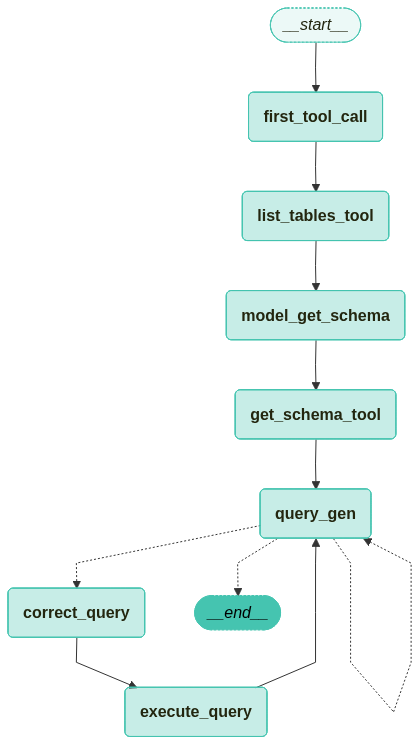

In [15]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app, xray=True)

## 그래프 실행

에이전트를 실행하여 SQL 데이터베이스와 상호작용하는 전체 프로세스를 진행합니다.

에이전트는 사용자의 질문에 따라 데이터베이스에서 정보를 검색하고, 쿼리를 생성 및 실행하여 결과를 반환합니다. 

In [16]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph, stream_graph
from langchain_core.messages import HumanMessage
from langgraph.errors import GraphRecursionError


def run_graph(
    message: str, recursive_limit: int = 30, node_names=[], stream: bool = False
):
    # config 설정(재귀 최대 횟수, thread_id)
    config = RunnableConfig(
        recursion_limit=recursive_limit, configurable={"thread_id": random_uuid()}
    )

    # 질문 입력
    inputs = {
        "messages": [HumanMessage(content=message)],
    }

    try:
        if stream:
            # 그래프 실행
            stream_graph(app, inputs, config, node_names=node_names)
        else:
            invoke_graph(app, inputs, config, node_names=node_names)
        output = app.get_state(config).values
        return output
    except GraphRecursionError as recursion_error:
        print(f"GraphRecursionError: {recursion_error}")
        output = app.get_state(config).values
        return output

In [17]:
output = run_graph(
    "Andrew Adam 직원의 인적정보를 모두 조회해줘",
    stream=False,
)


🔄 Node: first_tool_call 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_abc123)
 Call ID: initial_tool_call_abc123
  Args:

🔄 Node: list_tables_tool 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

🔄 Node: model_get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'id': 'toolu_01NU5ShqNyEedzMZft8Giryd', 'input': {'table_names': 'Employee'}, 'name': 'sql_db_schema', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  sql_db_schema (toolu_01NU5ShqNyEedzMZft8Giryd)
 Call ID: toolu_01NU5ShqNyEedzMZft8Giryd
  Args:
    table_names: Em

In [18]:
output = run_graph(
    "2009년도에 어느 국가의 고객이 가장 많이 지출했을까요? 그리고 얼마를 지출했을까요? 한글로 답변하세요.",
    stream=False,
)


🔄 Node: first_tool_call 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_abc123)
 Call ID: initial_tool_call_abc123
  Args:

🔄 Node: list_tables_tool 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

🔄 Node: model_get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

[{'id': 'toolu_0184UtN32Dyd4ExCExVPhHyw', 'input': {'table_names': 'Invoice, Customer'}, 'name': 'sql_db_schema', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  sql_db_schema (toolu_0184UtN32Dyd4ExCExVPhHyw)
 Call ID: toolu_0184UtN32Dyd4ExCExVPhHyw
  Args:
    table_

## LangSmith Evaluator를 활용한 SQL Agent 평가

이제 생성한 Agent의 SQL 쿼리 응답을 평가합니다. 에이전트 평가는 단순히 코드가 실행되는지 확인하는 것이 아니라, 실제 질문에 대해 올바른 답변을 생성하는지 체계적으로 검증하는 중요한 과정입니다. LangSmith를 활용하면 평가 결과를 시각화하고 관리하며, 모델 또는 프롬프트 변경 시 성능 변화를 쉽게 비교·분석할 수 있습니다.

평가를 위해 다음 단계를 수행합니다:

1. **평가용 데이터셋 생성**: 질문과 정답 쌍으로 구성된 데이터셋을 LangSmith에 업로드
2. **예측 함수 정의**: 에이전트의 응답을 예측하는 함수 정의
3. **평가자 정의**: LLM-as-judge 방식의 평가자 정의
4. **평가 실행**: 데이터셋에 대해 평가를 수행하고 결과 확인

평가용 데이터셋은 `(질문, 정답)` 형태의 예제 쌍으로 구성됩니다. 데이터셋이 이미 LangSmith에 존재하는 경우에는 새로 생성하지 않고 기존 데이터셋을 재사용하여 실험의 일관성을 유지합니다. 아래 코드는 5개의 테스트 예제를 포함하는 데이터셋을 생성하고 LangSmith에 업로드합니다.

In [19]:
from langsmith import Client

# 클라이언트 초기화
client = Client()

# 데이터셋 생성 및 업로드
examples = [
    (
        "Which country's customers spent the most? And how much did they spend?",
        "The country whose customers spent the most is the USA, with a total spending of 523.06.",
    ),
    (
        "What was the most purchased track of 2013?",
        "The most purchased track of 2013 was Hot Girl.",
    ),
    (
        "How many albums does the artist Led Zeppelin have?",
        "Led Zeppelin has 14 albums",
    ),
    (
        "What is the total price for the album “Big Ones”?",
        "The total price for the album 'Big Ones' is 14.85",
    ),
    (
        "Which sales agent made the most in sales in 2009?",
        "Steve Johnson made the most sales in 2009",
    ),
]

dataset_name = "SQL Agent Response"

if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    inputs, outputs = zip(
        *[({"input": text}, {"output": label}) for text, label in examples]
    )
    client.create_examples(inputs=inputs, outputs=outputs, dataset_id=dataset.id)

다음으로는 에이전트의 SQL 쿼리 응답을 예측하기 위한 함수를 정의합니다. 이 함수는 입력 질문을 받아 에이전트를 실행하고 최종 응답을 반환합니다.

In [20]:
# 에이전트의 SQL 쿼리 응답을 예측하기 위한 함수 정의
def predict_sql_agent_answer(example: dict):
    """평가를 위한 SQL 에이전트 응답 예측 함수입니다.

    입력 질문을 에이전트에 전달하고 최종 응답을 추출하여 반환합니다.
    SubmitFinalAnswer 도구 호출 시 final_answer 필드에서 답변을 추출합니다.
    """
    config = RunnableConfig(configurable={"thread_id": random_uuid()})

    inputs = {
        "messages": [HumanMessage(content=example["input"])],
    }
    # 그래프를 실행하여 메시지 결과 조회
    messages = app.invoke(inputs, config)
    last_message = messages["messages"][-1]

    # SubmitFinalAnswer 도구 호출 시 final_answer 필드에서 답변 추출
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tc in last_message.tool_calls:
            if tc["name"] == "SubmitFinalAnswer":
                return {"response": tc["args"].get("final_answer", "")}

    # 텍스트 형태로 답변이 반환된 경우
    return {"response": last_message.content}

SQL 쿼리 응답을 평가하기 위한 프롬프트와 평가자(LLM-as-judge)를 정의합니다. LLM-as-judge 방식은 LLM이 생성한 응답을 또 다른 LLM이 평가하는 방식으로, 자연어로 표현된 답변의 정확성을 자동으로 측정하는 데 효과적입니다. 고정된 규칙으로 평가하기 어려운 자유 형식의 텍스트 응답을 처리할 때 특히 유용하며, `langchain-ai/rag-answer-vs-reference` 허브 프롬프트와 동일한 기준으로 직접 프롬프트를 정의합니다.

`with_structured_output()`은 LLM의 응답을 Pydantic 모델과 같은 구조화된 형식으로 안정적으로 추출할 수 있게 해주는 기능입니다. 일반 텍스트 파싱 대신 구조화된 출력을 사용하면 점수 추출 과정에서 발생할 수 있는 파싱 오류를 최소화하고, 일관된 형식의 결과를 얻을 수 있습니다. 평가자는 예측 답변과 참조 답변을 비교하여 정확도 점수(0 또는 1)를 반환합니다.

> 📖 **참고 문서**: [with_structured_output](https://python.langchain.com/docs/concepts/structured_outputs/)

아래 코드는 `GradeAnswer` 스키마와 `answer_evaluator` 함수를 정의합니다.

In [25]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field


# 답변 정확도 평가 점수 스키마 정의
class GradeAnswer(BaseModel):
    """답변의 정확도를 평가하는 점수 스키마"""

    Score: int = Field(description="0 means incorrect, 1 means correct")


# 답변 정확도 평가 프롬프트 정의 (langchain-ai/rag-answer-vs-reference 기준 동일)
grade_prompt_answer_accuracy = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Grade the student answers being not strictly wrong.
(2) Ensure the student answer does not contradict the correct answer.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is not contradictory.

Score: 1 means the student's answer meets all of the criteria. This is the highest (best) score.
Score: 0 means the student's answer does not meet all of the criteria. This is the lowest possible score you can give.""",
        ),
        (
            "human",
            "QUESTION: {question}\n\nGROUND TRUTH ANSWER: {correct_answer}\n\nSTUDENT ANSWER: {student_answer}",
        ),
    ]
)


# 답변 평가자 LLM-as-judge 정의
def answer_evaluator(run, example) -> dict:
    """LLM-as-judge 방식으로 에이전트 응답의 정확도를 평가합니다.

    참조 답변과 예측 답변을 비교하여 정확도 점수(0 또는 1)를 반환합니다.
    """
    # input: 질문
    input_question = example.inputs["input"]
    # output: 참조 답변
    reference = example.outputs["output"]
    # 예측 답변
    prediction = run.outputs["response"]

    # OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등의 모델로 변경하세요
    # LLM 평가자 초기화 (structured output으로 점수를 안정적으로 추출)
    llm = init_chat_model("claude-sonnet-4-5", temperature=0)
    answer_grader = grade_prompt_answer_accuracy | llm.with_structured_output(
        GradeAnswer
    )

    # 평가자 실행
    score = answer_grader.invoke(
        {
            "question": input_question,
            "correct_answer": reference,
            "student_answer": prediction,
        }
    )

    # 점수 반환
    return {"key": "answer_v_reference_score", "score": score.Score}

이제 LangSmith의 `evaluate()` 함수를 사용하여 실제 평가를 수행합니다. `evaluate()` 함수는 데이터셋의 각 예제를 예측 함수에 전달하고, 반환된 결과를 평가자가 채점하는 전체 파이프라인을 자동으로 실행합니다. 평가가 진행되는 동안 결과는 LangSmith 대시보드에 실시간으로 업로드되어 바로 확인할 수 있습니다.

`num_repetitions` 파라미터를 설정하면 동일한 테스트를 여러 번 반복 실행할 수 있습니다. LLM 응답에는 확률적 특성이 있어 동일한 질문에도 다소 다른 답변이 생성될 수 있으므로, 반복 실행을 통해 평균적인 성능을 측정하는 것이 중요합니다. `experiment_prefix`는 LangSmith에서 실험을 식별하는 이름 접두사로, 여러 실험의 결과를 구분하고 비교 분석할 때 활용됩니다.

아래 코드는 `sql-agent-eval` 실험을 3회 반복 실행하고 평가 결과를 LangSmith에 기록합니다.

In [26]:
from langsmith.evaluation import evaluate

# 평가용 데이터셋 이름
dataset_name = "SQL Agent Response"

try:
    # 평가 진행
    experiment_results = evaluate(
        predict_sql_agent_answer,  # 평가시 활용할 예측 함수
        data=dataset_name,  # 평가용 데이터셋 이름
        evaluators=[answer_evaluator],  # 평가자 목록
        num_repetitions=3,  # 실험 반복 횟수 설정
        experiment_prefix="sql-agent-eval",
        metadata={
            "version": "chinook db, sql-agent-eval: claude-sonnet-4-5"
        },  # 실험 메타데이터
    )
except Exception as e:
    print(e)

View the evaluation results for experiment: 'sql-agent-eval-022152f5' at:
https://smith.langchain.com/o/42ebd69b-2565-441c-b868-9709c2e20267/datasets/3e801af3-038d-445d-887b-379a30a14939/compare?selectedSessions=e048c123-2df9-4af2-ae12-cc8f56ea2246




0it [00:00, ?it/s]

평가 결과는 생성된 URL에서 확인할 수 있습니다. LangSmith 대시보드에서 각 실험의 상세 결과를 분석할 수 있습니다.

![](./assets/langgraph-sql-agent-evaluation.png)